# ASSUMPTIONS

In [ ]:
import numpy as np

ASSUMPTIONS = {
    #
    "year": 2026,
    "month": 7,                          # July
    "timezone": "America/New_York",      # JAX is in the Eastern time zone
    "interval_minutes": 15,              # utilities meter demand in 15-min slices
    "random_seed": 42,                   # locks the "random" numbers so every run matches

    "power_kw_by_type": {
        "level_2": 7.0,                  # all 11 of JAX's ports are Level 2
    },

    #for each car
    "energy_needed_kwh": 25.0,           # ~80-100 miles; starting guess from the project notes
    "occupied_share": 0.80,              # assumption: 80% of ports occupied at any time

    # to clarify how long a car occupies a port.

    "stay_mix": {
    "daily_garage": {
        "hours":   [4,    24,   48],
        "weights": [0.30, 0.45, 0.25],
        },
    "economy": {
        "hours":   [72],      # always 3 days,
        "weights": [1.0],     # 100% of the time, but can change the weights later
        },
    },

    # When cars can arrive (24h window — JAX has no short-stay hourly lot) ---
    "arrival_hours": list(range(24)),

    # Relative weights, — just the shape of the day
    "arrival_weights": [
        1, 1, 1, 1, 2,       # midnight-5am: quiet
        8, 12, 15, 14, 10,   # 5-10am: main peak
        5, 4, 4, 4, 5,       # 10am-3pm: steady midday
        7, 8, 6,             # 3-6pm: smaller afternoon bump
        4, 3, 2, 2, 1, 1,    # 6pm-midnight: tapering off
    ],

    # JAX's port inventory: 8 ports at the daily garage, 3 at economy
    # only using one type of charger so far

    "lot_setup": {
        "daily_garage": {"ports": 8, "charger_type": "level_2"},
        "economy":      {"ports": 3, "charger_type": "level_2"},
    },


    # Source for each number above
    # don't forget to change this text if I change anything later on
    "sources": {
        "power_kw_by_type": "JAX inventory: 0 L1, 11 L2, 0 DC fast (data collection).",
        "energy_needed_kwh": "Starting guess: 25 kWh per car (project notes).",
        "occupied_share": "Starting guess: 80% occupied (project notes).",
        "stay_mix": (
            "daily_garage: user-provided distribution, 30% stay 4h, 45% stay "
            "24h, 25% stay 48h. economy: flat 72h (3 days), the project's "
            "suggested starting guess for economy lots."
        ),
        "arrival_weights": "Illustrative 5-10am peak with a smaller 3-6pm bump; shape is a guess.",
        "lot_setup": "JAX ports: 8 L2 in Daily Garage/Surface/Valet, 3 L2 in Economy Lot 3.",
        "random_seed": "Reproducibility setting: 42 normally; temporarily set to 7 to check seed sensitivity.",
        "simulation_period": "July 2026, JAX local (Eastern) time.",
    },
}

YEAR = ASSUMPTIONS["year"]
MONTH = ASSUMPTIONS["month"]
TIMEZONE = ASSUMPTIONS["timezone"]
SEED = ASSUMPTIONS["random_seed"]
INTERVAL_MINUTES = ASSUMPTIONS["interval_minutes"]

arrival_weights = np.array(ASSUMPTIONS["arrival_weights"], dtype=float)

# each lot has a dictionary, so later code never has to dig into ASSUMPTIONS
lots = {}
for lot_name, setup in ASSUMPTIONS["lot_setup"].items():
    mix = ASSUMPTIONS["stay_mix"][lot_name]
    lots[lot_name] = {
        "ports": setup["ports"],
        "power_kw": ASSUMPTIONS["power_kw_by_type"][setup["charger_type"]],
        "stay_hours": np.array(mix["hours"], dtype=float),
        "stay_weights": np.array(mix["weights"], dtype=float),
        "occupied_share": ASSUMPTIONS["occupied_share"],
        "arrival_hours": ASSUMPTIONS["arrival_hours"],
        "energy_needed_kwh": ASSUMPTIONS["energy_needed_kwh"],
    }

rng = np.random.default_rng(SEED)

Sanity check:
The following cell prints what I produced in **lots**




In [ ]:
for lot_name, lot in lots.items():
    print(lot_name)
    print("  stay_hours  :", lot["stay_hours"])
    print("  stay_weights:", lot["stay_weights"])
    print("  ports       :", lot["ports"], " power_kw:", lot["power_kw"])

daily_garage
  stay_hours  : [ 4. 24. 48.]
  stay_weights: [0.3  0.45 0.25]
  ports       : 8  power_kw: 7.0
economy
  stay_hours  : [72.]
  stay_weights: [1.]
  ports       : 3  power_kw: 7.0


# EMPTY TIMELINE

In [ ]:
import pandas as pd

#empty timeline for the month, every kW starting at 0

#builds one point in time, pulls YEAR, MONTH from ASSUMPTIONS
month_start = pd.Timestamp(year=YEAR, month=MONTH, day=1)
#steps forward one month (to August 1)
month_end = month_start + pd.offsets.MonthBegin(1)

#timeline: generates every timestamp from month_start to month_end
timestamps = pd.date_range(
    start=month_start,
    end=month_end,
    freq=f"{INTERVAL_MINUTES}min",
    inclusive="left",
)
#includes starting timetamp 07-01 00:00,
#does not include not 08-01 00:00

#build table, timestamp column and kW column
load_profile = pd.DataFrame({
    "timestamp": timestamps,
    "kW": 0.0,
})

load_profile.head()

,timestamp,kW
0,2026-07-01 00:00:00,0.0
1,2026-07-01 00:15:00,0.0
2,2026-07-01 00:30:00,0.0
3,2026-07-01 00:45:00,0.0
4,2026-07-01 01:00:00,0.0


# Step 2. calculate how many cars arrive every day

Slight difference in my code: My lots are written to have a *mix* of posisble stays, so I will use the **mean** stay length with a weighted average in place of a single stay number

In [ ]:
HOURS_PER_DAY = 24

for lot_name, lot in lots.items():
    # Compute the weighted average. For daily_garage, the average is 24h.
    # For economy, 72h
    mean_stay_hours = float(np.dot(lot["stay_hours"], lot["stay_weights"]))
    # If I ever add a short-stay hourly lot later,
    # this will adjust for new busy hours
    busy_hours_per_day = len(lot["arrival_hours"])  # 24 for both JAX lots — no short-stay hourly lot here

    # Formula from the notes to compute cars per port
    cars_per_port_per_day = lot["occupied_share"] * busy_hours_per_day / mean_stay_hours
    # multiplies by # of ports to compute how many cars per day
    cars_per_day = cars_per_port_per_day * lot["ports"]

    # Store these back onto the lot, so later steps don't recompute them
    # My car spawner will just read off of this
    lot["mean_stay_hours"] = mean_stay_hours
    lot["cars_per_day"] = cars_per_day

    print(f"{lot_name}:")
    print(f"  mean stay          : {mean_stay_hours:.2f} h")
    print(f"  cars per port/day   : {cars_per_port_per_day:.3f}")
    print(f"  cars per day (lot)  : {cars_per_day:.2f}")

daily_garage:
  mean stay          : 24.00 h
  cars per port/day   : 0.800
  cars per day (lot)  : 6.40
economy:
  mean stay          : 72.00 h
  cars per port/day   : 0.267
  cars per day (lot)  : 0.80


Sanity check for how many cars will be produced over the month


In [ ]:
intervals_per_day = int(24 * 60 / INTERVAL_MINUTES)      # 96
days_in_month = len(load_profile) // intervals_per_day    # 31 for July

for lot_name, lot in lots.items():
    total_cars = lot["cars_per_day"] * days_in_month
    print(f"{lot_name}: ~{total_cars:.1f} cars over the month")

daily_garage: ~198.4 cars over the month
economy: ~24.8 cars over the month


# STEP 3: Give each car an arrival time and a energy requirement
arrival time drawn from the arrival pattern

In [ ]:
# determine how many cars arrive on a given day, and when

for lot_name, lot in lots.items():
    # using a posson distribution to determine the number of arrivals in a day
    n_arrivals_today = rng.poisson(lot["cars_per_day"])

    # Each arrival gets an hour-of-day, weighted by arrival_weights
    # (normalized so the weights sum to 1)
    hour_probs = arrival_weights / arrival_weights.sum() #normalized
    arrival_hours_today = rng.choice(
        lot["arrival_hours"], size=n_arrivals_today, p=hour_probs
    )

    # Every car's needed energy level, repeating 25 kWh per car
    # TO BE CHANGED if I ever need to vary the energy for different cars (so it is written as an array)
    energy_needed_today = np.full(n_arrivals_today, lot["energy_needed_kwh"])

    # each car stay will be drawn from the lot's mix
    stay_hours_today = rng.choice(
        lot["stay_hours"], size=n_arrivals_today, p=lot["stay_weights"]
    )
    print(f"{lot_name}: {n_arrivals_today} cars")
    for h, e, s in zip(sorted(arrival_hours_today), energy_needed_today, stay_hours_today):
        print(f"  arrives at hour {h:>2}, needs {e:.0f} kWh, stays {s:.0f} h")

daily_garage: 6 cars
  arrives at hour  5, needs 25 kWh, stays 48 h
  arrives at hour  6, needs 25 kWh, stays 48 h
  arrives at hour  7, needs 25 kWh, stays 4 h
  arrives at hour  8, needs 25 kWh, stays 4 h
  arrives at hour 14, needs 25 kWh, stays 4 h
  arrives at hour 20, needs 25 kWh, stays 24 h
economy: 1 cars
  arrives at hour  4, needs 25 kWh, stays 72 h


In [ ]:
#In the cell above, I created three separate arrays (arrival hours, energy needed, stay hours)
# so that I could print the effect of each one. Now, I will bundle each car into one record
#CELL CAN ONLY RUN if lots, rng, arrival_weights exist

def generate_cars_for_day(lot, lot_name, rng, arrival_weights):
    """Return a list of car dicts for one lot, one day."""
    n_arrivals = rng.poisson(lot["cars_per_day"])

    hour_probs = arrival_weights / arrival_weights.sum()
    arrival_hours = rng.choice(lot["arrival_hours"], size=n_arrivals, p=hour_probs)
    stay_hours = rng.choice(lot["stay_hours"], size=n_arrivals, p=lot["stay_weights"])

# each car is described by its own lot, arrival_hour, energy_kwh, stay_hours
    cars = []
    for hour, stay in zip(arrival_hours, stay_hours):
        cars.append({
            "lot": lot_name,
            "arrival_hour": hour,
            "energy_kwh": lot["energy_needed_kwh"],
            "stay_hours": stay,
        })
    return cars

# try it for one day, one lot:
sample_cars = generate_cars_for_day(lots["daily_garage"], "daily_garage", rng, arrival_weights)
for car in sorted(sample_cars, key=lambda c: c["arrival_hour"]):
    print(car)

{'lot': 'daily_garage', 'arrival_hour': np.int64(7), 'energy_kwh': 25.0, 'stay_hours': np.float64(4.0)}
{'lot': 'daily_garage', 'arrival_hour': np.int64(8), 'energy_kwh': 25.0, 'stay_hours': np.float64(24.0)}
{'lot': 'daily_garage', 'arrival_hour': np.int64(9), 'energy_kwh': 25.0, 'stay_hours': np.float64(4.0)}
{'lot': 'daily_garage', 'arrival_hour': np.int64(21), 'energy_kwh': 25.0, 'stay_hours': np.float64(4.0)}


Loop: For every day in the month, for every lot, generate that day's cars, then for each car add its charging draw into load_profile


In [ ]:
days_in_month = (month_end - month_start).days
intervals_per_day = int(24 * 60 / INTERVAL_MINUTES)  # 96

all_cars = []  # we'll keep a record of every car for later checks

for day in range(days_in_month):
    for lot_name, lot in lots.items():
        cars_today = generate_cars_for_day(lot, lot_name, rng, arrival_weights)

        for car in cars_today:
            # Hours since the start of the month this car plugs in.
            arrival_hours_into_month = day * 24 + car["arrival_hour"]

            # Round down to the nearest interval boundary (project notes:
            # "snap arrivals down" so only the END of a charge is partial).
            start_interval = int(arrival_hours_into_month * 60 // INTERVAL_MINUTES)

            # How long this car actually charges: energy need / port power,
            # capped by how long it stays (can't charge longer than it's there).
            charge_hours = min(
                car["energy_kwh"] / lot["power_kw"],
                car["stay_hours"],
            )
            charge_intervals = charge_hours * 60 / INTERVAL_MINUTES

            car["start_interval"] = start_interval
            car["charge_intervals"] = charge_intervals
            all_cars.append(car)

print(f"total cars generated: {len(all_cars)}")
print(all_cars[0])
print(all_cars[-1])

total cars generated: 238
{'lot': 'daily_garage', 'arrival_hour': np.int64(6), 'energy_kwh': 25.0, 'stay_hours': np.float64(24.0), 'start_interval': 24, 'charge_intervals': 14.285714285714286}
{'lot': 'economy', 'arrival_hour': np.int64(23), 'energy_kwh': 25.0, 'stay_hours': np.float64(72.0), 'start_interval': 2972, 'charge_intervals': 14.285714285714286}


the following cell will now add kW to my timeline, assigning the ports.


In [ ]:
n_rows = len(load_profile)
kw = np.zeros(n_rows) # build the result here, then drop it into load_profile at the end

for lot_name, lot in lots.items():
# One slot per port: this holds the interval index it becomes free at. 0 = free from the start.
    port_free_at = np.zeros(lot["ports"])
    # Pull out just this lot's cars, sorted by when they arrive
    # port availability depends on processing earlier cars first.
    lot_cars = [c for c in all_cars if c["lot"] == lot_name]
    lot_cars.sort(key=lambda c: c["start_interval"])

    for car in lot_cars:
        stay_intervals = car["stay_hours"] * 60 / INTERVAL_MINUTES
        # finds which ports are free by the time this car shows up
        free_ports = np.nonzero(port_free_at <= car["start_interval"])[0]

        if free_ports.size == 0:
            car["served"] = False #no free port --> turn away
            car["delivered_kwh"] = 0.0
            continue

        port = free_ports[0] #grab the lowest indexed port
        # occupies the chosen port until the car's stay ends
        port_free_at[port] = car["start_interval"] + stay_intervals
        car["served"] = True

        # Add this car's draw onto every interval it's actually charging
        start = car["start_interval"]
        full_intervals = int(car["charge_intervals"])
        partial = car["charge_intervals"] - full_intervals #a fraction of full power in the next interval
        delivered = 0.0  # FIXED: accumulate what actually lands inside the month

        for i in range(full_intervals):
            idx = start + i
            if 0 <= idx < n_rows:
                kw[idx] += lot["power_kw"]
                delivered += lot["power_kw"] * (INTERVAL_MINUTES / 60)

        idx = start + full_intervals
        if 0 <= idx < n_rows and partial > 1e-9:
            kw[idx] += lot["power_kw"] * partial
            delivered += lot["power_kw"] * partial * (INTERVAL_MINUTES / 60)

        car["delivered_kwh"] = delivered  # new: store it on the car

# then write the finished array into the table
load_profile["kW"] = kw

served = sum(c.get("served", False) for c in all_cars)
turned_away = sum(not c.get("served", False) for c in all_cars)
print(f"served: {served}, turned away: {turned_away}")

served: 204, turned away: 34


# Cell to check my work, written entirely by Claude

In [ ]:
# --- Step 2.8: sanity checks, straight from the project notes ---

ceiling_kw = sum(lot["ports"] * lot["power_kw"] for lot in lots.values())
checks = []

checks.append((
    load_profile["kW"].max() <= ceiling_kw + 1e-9,
    f"peak kW ({load_profile['kW'].max():.1f}) never exceeds the ceiling ({ceiling_kw:.0f} kW)"
))

checks.append((
    (load_profile["kW"] >= 0).all(),
    "no negative kW values"
))

checks.append((
    not load_profile["kW"].isna().any(),
    "no missing values"
))

checks.append((
    len(load_profile) == 31 * 96,
    f"row count ({len(load_profile)}) matches July's expected 2976"
))

expected_kwh = sum(c.get("delivered_kwh", 0.0) for c in all_cars if c.get("served"))
total_kwh = load_profile["kW"].sum() * (INTERVAL_MINUTES / 60)

checks.append((
    abs(total_kwh - expected_kwh) < 0.01,
    f"total kWh delivered ({total_kwh:.1f}) matches sum of each car's actual delivered kWh ({expected_kwh:.1f})"
))

for ok, label in checks:
    print(f"[{'OK' if ok else 'FAIL'}] {label}")

[OK] peak kW (49.0) never exceeds the ceiling (77 kW)
[OK] no negative kW values
[OK] no missing values
[OK] row count (2976) matches July's expected 2976
[OK] total kWh delivered (5082.0) matches sum of each car's actual delivered kWh (5082.0)


NEXT:
plot one week and create a csv file

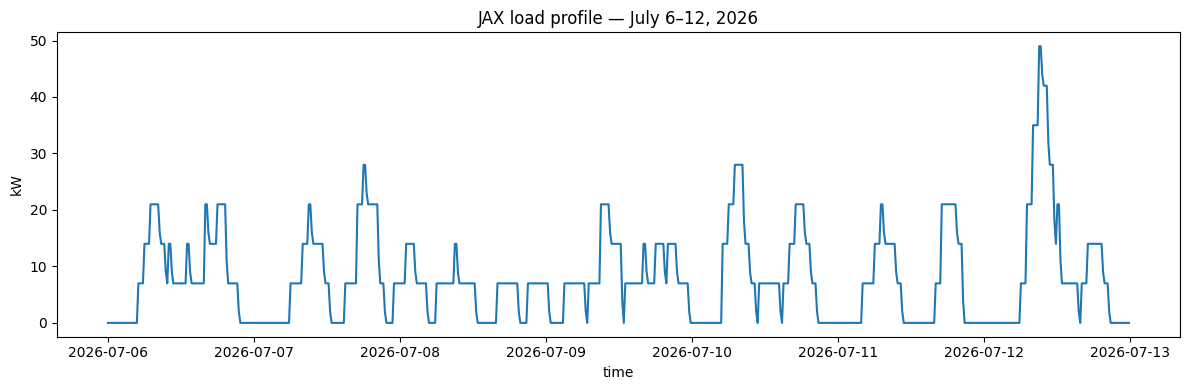

wrote loadprofile_JAX_2026-07.csv


In [ ]:
import matplotlib.pyplot as plt

week = load_profile[
    (load_profile["timestamp"] >= "2026-07-06") &
    (load_profile["timestamp"] < "2026-07-13")
]

plt.figure(figsize=(12, 4))
plt.plot(week["timestamp"], week["kW"])
plt.title("JAX load profile — July 6–12, 2026")
plt.xlabel("time")
plt.ylabel("kW")
plt.tight_layout()
plt.show()

filename = f"loadprofile_JAX_{YEAR}-{MONTH:02d}.csv"
load_profile.to_csv(filename, index=False)
print(f"wrote {filename}")

In [ ]:
#from google.colab import files
#files.download(filename)

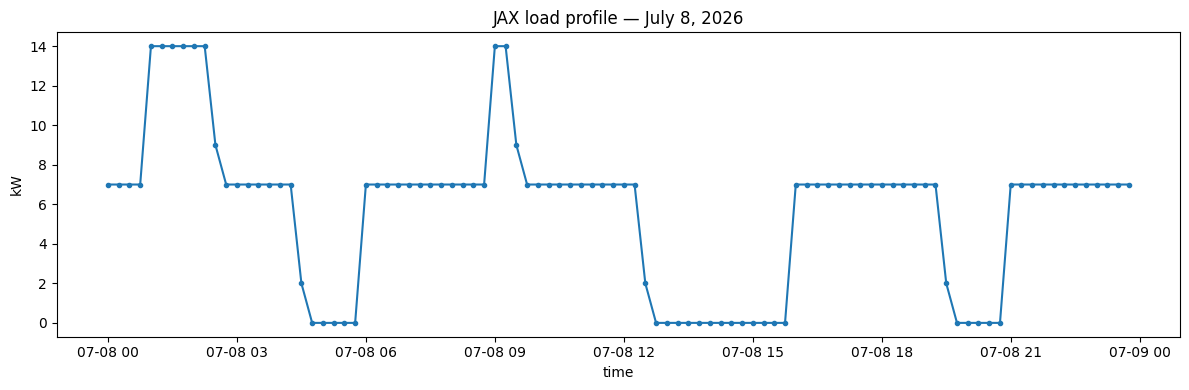

In [ ]:
#zoom in on a single day

day = load_profile[
    (load_profile["timestamp"] >= "2026-07-08") &
    (load_profile["timestamp"] < "2026-07-09")
]

plt.figure(figsize=(12, 4))
plt.plot(day["timestamp"], day["kW"], marker="o", markersize=3)
plt.title("JAX load profile — July 8, 2026")
plt.xlabel("time")
plt.ylabel("kW")
plt.tight_layout()
plt.show()

In [ ]:
print("peak kW:", load_profile["kW"].max())
print("total kWh:", load_profile["kW"].sum() * (INTERVAL_MINUTES / 60))
print("served / turned away:", served, "/", turned_away)

peak kW: 49.0
total kWh: 5082.0
served / turned away: 204 / 34
